# check this

In [1]:
import pandas as pd  

df = pd.read_csv("C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/train_FD001_processed.csv")

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,s2,s3,s4,s6,s7,s8,...,s8_diff,s9_diff,s11_diff,s12_diff,s13_diff,s14_diff,s15_diff,s17_diff,s20_diff,s21_diff
0,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,...,-0.04,-5.47,-0.12,-0.51,-0.01,-0.95,-0.0186,-2.0,0.08,-0.0375
1,1,7,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,...,0.00,9.45,0.20,0.64,0.00,-0.53,-0.0134,1.0,0.12,0.0105
2,1,8,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,...,-0.02,-18.33,-0.12,0.15,0.00,-1.25,0.0102,-1.0,-0.13,-0.0668
3,1,9,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,...,0.05,5.66,0.05,-0.68,0.02,-5.38,-0.0348,1.0,0.08,0.0960
4,1,10,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,...,0.00,5.24,-0.26,0.00,0.01,3.69,0.0558,1.0,-0.10,0.0628


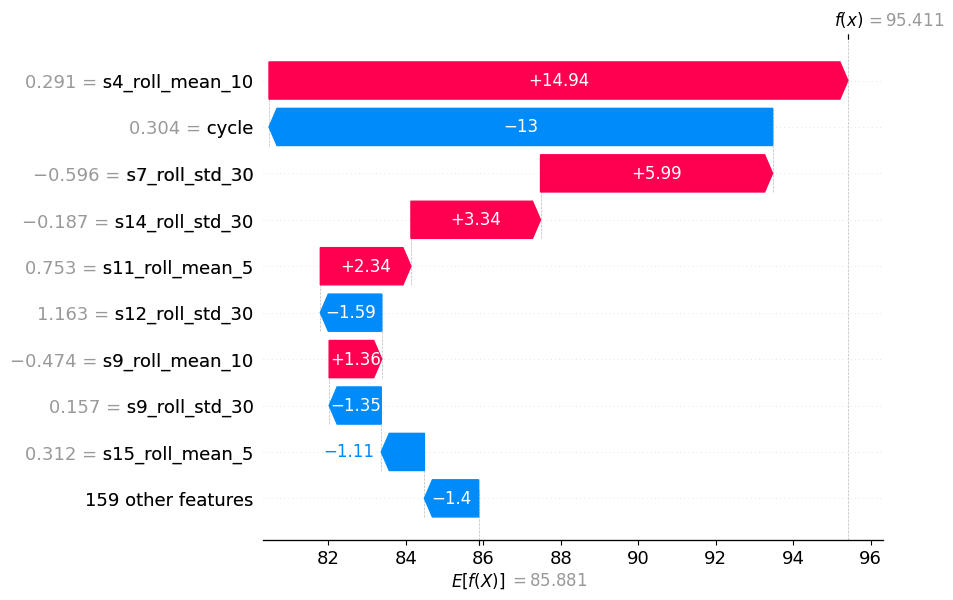

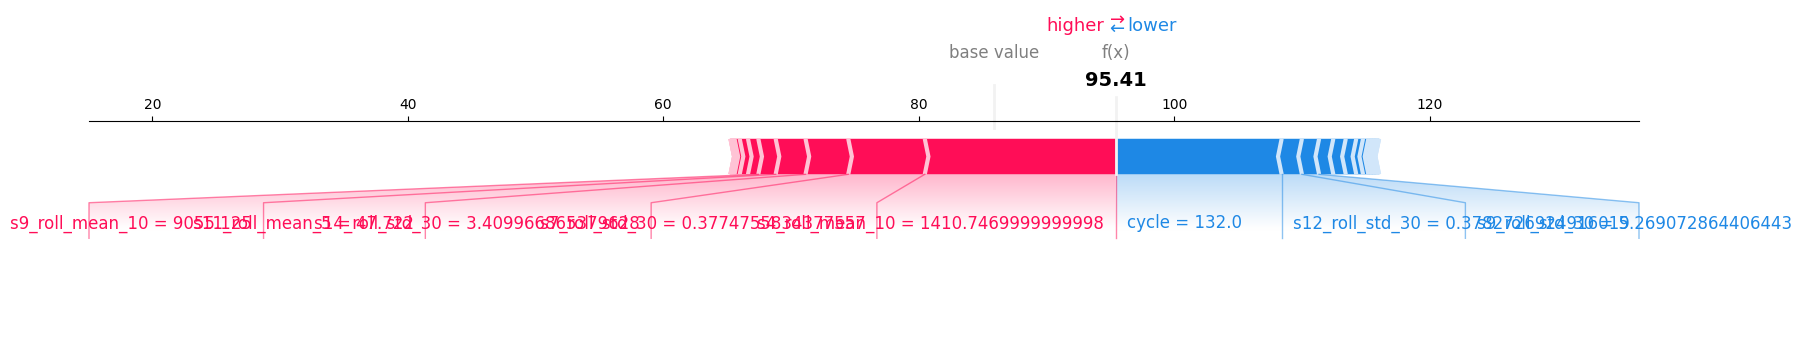

In [13]:
import mlflow
import shap

def get_shap_value():

    mlflow.set_tracking_uri("sqlite:///../mlflow.db")
    pipeline = mlflow.sklearn.load_model("models:/DecisionTree - FD001@challenger")

    model = pipeline.named_steps['model']
    scaler = pipeline.named_steps['scaler']

    X = df[scaler.feature_names_in_]

    explainer = shap.Explainer(model)
    shap_values = explainer(scaler.transform(X))
    
    return shap_values, explainer, X 

shap_values, explainer, X = get_shap_value()    


# 1. SHAP Waterfall Plot (Single prediction breakdown)
shap.plots.waterfall(shap.Explanation(values=shap_values[0],
                                      base_values=explainer.expected_value,
                                      data=X.iloc[0],
                                      feature_names=X.columns))


# 3. SHAP Force Plot (Single prediction - visual push/pull)
# For a single instance (e.g., first sample)
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[0].values,
    features=X.iloc[0],
    feature_names=X.columns,
    matplotlib=True  
)


In [12]:
import pandas as pd  
import numpy as np


df = pd.read_csv("C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/train_FD003_processed.csv")

# col_names = ["engine_id","cycle","op_setting_1","op_setting_2","op_setting_3"] + [f"s{i+1}" for i in range(df.shape[1] -5)]
col_names = ["engine_id","cycle","op_setting_1","op_setting_2","op_setting_3","s1","s2","s3","s4","s5","s6","s7","s8","s9","s10","s11","s12","s13","s14","s15","s16","s17","s18","s19","s20","s21"]
df = df[df['engine_id']==50]
df = df.iloc[-30:-22, :]
sample_data= {}
for col in col_names:
    sample_data[col]=list(df[col]) 

print(sample_data)



{'engine_id': [50, 50, 50, 50, 50, 50, 50, 50], 'cycle': [132, 133, 134, 135, 136, 137, 138, 139], 'op_setting_1': [0.0016, 0.0007, 0.0006, -0.0001, -0.0022, -0.0005, 0.0015, -0.0026], 'op_setting_2': [0.0004, 0.0001, 0.0002, -0.0002, 0.0004, -0.0003, -0.0001, 0.0004], 'op_setting_3': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's1': [518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67], 's2': [642.96, 642.67, 642.93, 642.74, 643.06, 643.4, 643.02, 642.43], 's3': [1594.74, 1591.92, 1593.23, 1594.17, 1593.9, 1597.69, 1591.62, 1596.31], 's4': [1408.37, 1416.33, 1416.01, 1417.15, 1416.76, 1415.35, 1418.24, 1415.06], 's5': [14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62], 's6': [21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61], 's7': [552.69, 553.38, 553.83, 553.24, 552.51, 553.33, 552.77, 552.47], 's8': [2388.13, 2388.16, 2388.18, 2388.17, 2388.13, 2388.16, 2388.2, 2388.15], 's9': [9056.22, 9059.65, 9051.88, 9054.01, 9052.19, 9058.81, 9046.78, 9045.

{'engine_id': [50, 50, 50, 50, 50, 50, 50, 50], 'cycle': [147, 148, 149, 150, 151, 152, 153, 154], 'op_setting_1': [0.0031, 0.0005, -0.0068, -0.0019, 0.0002, -0.0021, -0.0022, 0.0016], 'op_setting_2': [0.0002, 0.0, 0.0003, 0.0002, 0.0005, 0.0001, -0.0003, 0.0002], 'op_setting_3': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's1': [518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67], 's2': [643.34, 643.13, 643.35, 643.72, 643.17, 643.49, 643.26, 643.61], 's3': [1595.41, 1596.86, 1596.88, 1598.44, 1594.79, 1597.66, 1595.87, 1602.13], 's4': [1420.45, 1410.68, 1426.34, 1419.85, 1418.86, 1421.52, 1423.87, 1425.74], 's5': [14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62], 's6': [21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61], 's7': [552.33, 552.32, 552.2, 551.89, 552.22, 550.71, 551.76, 551.21], 's8': [2388.24, 2388.18, 2388.22, 2388.22, 2388.18, 2388.32, 2388.28, 2388.31], 's9': [9041.94, 9045.24, 9054.31, 9046.49, 9043.24, 9044.28, 9042.13, 9041.19], 's10': [1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3], 's11': [47.9, 48.06, 48.1, 48.17, 48.01, 47.96, 47.94, 48.16], 's12': [519.94, 520.52, 519.9, 519.83, 520.53, 520.05, 520.27, 520.25], 's13': [2388.16, 2388.26, 2388.22, 2388.3, 2388.25, 2388.29, 2388.23, 2388.22], 's14': [8124.48, 8120.67, 8124.73, 8125.56, 8117.4, 8120.34, 8122.55, 8119.31], 's15': [8.5555, 8.4781, 8.4395, 8.4859, 8.5297, 8.4985, 8.5061, 8.544], 's16': [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03], 's17': [396, 396, 395, 395, 397, 396, 396, 395], 's18': [2388, 2388, 2388, 2388, 2388, 2388, 2388, 2388], 's19': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's20': [38.72, 38.5, 38.53, 38.32, 38.68, 38.36, 38.68, 38.51], 's21': [23.0584, 23.1013, 23.2029, 23.1697, 23.1931, 23.1054, 23.0599, 23.1167]}



{'engine_id': [50, 50, 50, 50, 50, 50, 50, 50], 'cycle': [154, 155, 156, 157, 158, 159, 160, 161], 'op_setting_1': [0.0016, 0.0017, 0.0007, 0.0011, 0.001, -0.0018, 0.0026, -0.0024], 'op_setting_2': [0.0002, 0.0004, 0.0002, 0.0004, 0.0002, 0.0003, -0.0001, -0.0], 'op_setting_3': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's1': [518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67], 's2': [643.61, 643.48, 643.76, 643.44, 643.77, 643.3, 643.79, 643.94], 's3': [1602.13, 1595.25, 1600.04, 1600.75, 1604.93, 1605.88, 1600.81, 1604.0], 's4': [1425.74, 1426.16, 1423.02, 1420.61, 1422.92, 1431.36, 1434.32, 1439.12], 's5': [14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62], 's6': [21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61], 's7': [551.21, 552.27, 551.48, 551.34, 551.44, 551.55, 551.27, 551.67], 's8': [2388.31, 2388.25, 2388.21, 2388.23, 2388.31, 2388.25, 2388.28, 2388.33], 's9': [9041.19, 9040.85, 9052.18, 9038.45, 9041.53, 9049.68, 9050.44, 9040.55], 's10': [1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3], 's11': [48.16, 48.12, 48.16, 48.31, 48.07, 48.24, 48.15, 48.21], 's12': [520.25, 520.06, 520.22, 519.93, 519.49, 520.17, 519.67, 519.65], 's13': [2388.22, 2388.3, 2388.26, 2388.33, 2388.25, 2388.27, 2388.29, 2388.33], 's14': [8119.31, 8121.26, 8123.33, 8123.3, 8116.58, 8116.15, 8119.71, 8120.68], 's15': [8.544, 8.5076, 8.5095, 8.494, 8.5273, 8.5199, 8.5004, 8.5676], 's16': [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03], 's17': [395, 396, 396, 395, 396, 394, 397, 397], 's18': [2388, 2388, 2388, 2388, 2388, 2388, 2388, 2388], 's19': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's20': [38.51, 38.41, 38.47, 38.45, 38.56, 38.6, 38.41, 38.3], 's21': [23.1167, 23.1122, 23.1565, 23.0606, 23.1199, 23.0053, 23.1993, 23.1358]}



{'engine_id': [50, 50, 50, 50, 50, 50, 50, 50], 'cycle': [132, 133, 134, 135, 136, 137, 138, 139], 'op_setting_1': [0.0016, 0.0007, 0.0006, -0.0001, -0.0022, -0.0005, 0.0015, -0.0026], 'op_setting_2': [0.0004, 0.0001, 0.0002, -0.0002, 0.0004, -0.0003, -0.0001, 0.0004], 'op_setting_3': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's1': [518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67, 518.67], 's2': [642.96, 642.67, 642.93, 642.74, 643.06, 643.4, 643.02, 642.43], 's3': [1594.74, 1591.92, 1593.23, 1594.17, 1593.9, 1597.69, 1591.62, 1596.31], 's4': [1408.37, 1416.33, 1416.01, 1417.15, 1416.76, 1415.35, 1418.24, 1415.06], 's5': [14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62, 14.62], 's6': [21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61, 21.61], 's7': [552.69, 553.38, 553.83, 553.24, 552.51, 553.33, 552.77, 552.47], 's8': [2388.13, 2388.16, 2388.18, 2388.17, 2388.13, 2388.16, 2388.2, 2388.15], 's9': [9056.22, 9059.65, 9051.88, 9054.01, 9052.19, 9058.81, 9046.78, 9045.46], 's10': [1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3], 's11': [47.57, 47.74, 47.74, 47.58, 47.77, 47.85, 47.82, 47.8], 's12': [520.65, 520.86, 520.75, 521.09, 521.13, 521.17, 520.63, 520.86], 's13': [2388.12, 2388.14, 2388.16, 2388.09, 2388.15, 2388.21, 2388.19, 2388.21], 's14': [8129.08, 8128.1, 8137.09, 8140.16, 8136.0, 8129.42, 8127.21, 8126.65], 's15': [8.4422, 8.4802, 8.4662, 8.4844, 8.4085, 8.4866, 8.4579, 8.4827], 's16': [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03], 's17': [394, 394, 394, 394, 395, 395, 394, 394], 's18': [2388, 2388, 2388, 2388, 2388, 2388, 2388, 2388], 's19': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0], 's20': [38.73, 38.73, 38.7, 38.92, 38.74, 38.85, 38.51, 38.57], 's21': [23.2956, 23.204, 23.2741, 23.1984, 23.3566, 23.2295, 23.2438, 23.2745]}

In [ ]:
import yaml 
import mlflow 
import joblib
import os
import pandas as pd

def load_config():
    with open ("../config.yaml", "r") as f:
        return yaml.safe_load(f)
config = load_config()



uri = "sqlite:///../mlflow.db"

mlflow.set_tracking_uri(uri)

def load_model_form_mlflow():
    model_name = "LightGBM"
    ds_filename =  "FD001"
    
    reg_model_name = f"{model_name} - {ds_filename}" 
    model_uri = f"models:/{reg_model_name}@challenger"
    pipeline = mlflow.sklearn.load_model(model_uri)
    # print(pipeline)

    return pipeline


model_pipeline = load_model_form_mlflow()

df = pd.read_csv("C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/train_FD003_processed.csv")
y = df["RUL"]   
X = df[model_pipeline.feature_names_in_]

model = model_pipeline.named_steps['model']
scaler = model_pipeline.named_steps['scaler']

X_scaled = scaler.transform(X) 

print(model)


model.fit(
    X_scaled, 
    y, 
    init_model=model.booster_,  # or just init_model=model
    eval_set=[(X_scaled, y)]
)

# joblib.dump(model_pipeline, "tune_lightgbm.pkl")

LGBMRegressor(bagging_fraction=0.6692842552013312,
              feature_fraction=0.8265939150488094,
              learning_rate=0.07808644392849808, max_depth=4,
              min_child_samples=60, min_split_gain=0.9608975841601337,
              n_estimators=350, num_leaves=30, random_state=42,
              reg_alpha=6.798047889045054e-08, reg_lambda=0.10701114031825339)
[LightGBM] [Warning] feature_fraction is set=0.8265939150488094, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8265939150488094
[LightGBM] [Warning] bagging_fraction is set=0.6692842552013312, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6692842552013312
[LightGBM] [Warning] feature_fraction is set=0.8265939150488094, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8265939150488094
[LightGBM] [Warning] bagging_fraction is set=0.6692842552013312, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6692842552013312
[LightGBM] [Warning]

['tune_lightgbm.pkl']

             Ridge      RF      LGBM      XGB   

nasa-s-score  375       483     340       389 

RMSE:         16.24    15.60    14.50    15.12           

RMSE_all:    15.30    14.49    14.75    14.38

In [21]:
import pandas as pd
a= "C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/FD001_features.csv"
b= "C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/train_FD001_features.csv"

# df_a = pd.read_csv(a)
df_b = pd.read_csv(b)
df_b.shape

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/processed/CMAPSSData/train_FD001_features.csv'

In [ ]:
a = "Ridge.pkl"
a.split('.pkl')

['Ridge', '']

In [ ]:
from markitdown import MarkItDown
import pandas as pd
import numpy as np


md = MarkItDown()

path= "C:/Users/91620/OneDrive/Desktop/codtech/1_predictive-maintenance-cmapss/data/raw/CMAPSSData/train_FD003.txt"

df = pd.read_csv(path, sep='\s+', header=None)

df     

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24715,100,148,-0.0016,-0.0003,100.0,518.67,643.78,1596.01,1424.11,14.62,...,519.66,2388.30,8138.08,8.5036,0.03,394,2388,100.0,38.44,22.9631
24716,100,149,0.0034,-0.0003,100.0,518.67,643.29,1596.38,1429.14,14.62,...,519.91,2388.28,8144.36,8.5174,0.03,395,2388,100.0,38.50,22.9746
24717,100,150,-0.0016,0.0004,100.0,518.67,643.84,1604.53,1431.41,14.62,...,519.44,2388.24,8135.95,8.5223,0.03,396,2388,100.0,38.39,23.0682
24718,100,151,-0.0023,0.0004,100.0,518.67,643.94,1597.56,1426.57,14.62,...,520.01,2388.26,8141.24,8.5148,0.03,395,2388,100.0,38.31,23.0753


In [ ]:
import os

all_models = []
ds_id = os.listdir('../models/')
for id in ds_id:
   model_list= os.listdir(f'../models/{id}')
   for model in model_list:
      if model != 'scaler.pkl':
            all_models.append(model.split('.pkl')[0]+ f"_{id}")
all_models 




['LightGBM_FD001', 'RandomForest_FD001', 'Ridge_FD001', 'XGBoost_FD001']

In [ ]:
a = "LightGBM-FD001"

b = a.split("-")


['LightGBM', 'FD001']

In [ ]:
import requests
import requests
from IPython.display import Image

url = "https://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-07&end_date=2015-09-08&api_key=MRgQ5nakjoVAxEqOgQeaOfduxtlPs5ZKvHgGJqXi"

response = requests.get(url)

data = response.json()

data

{'links': {'next': 'http://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-08&end_date=2015-09-09&detailed=false&api_key=MRgQ5nakjoVAxEqOgQeaOfduxtlPs5ZKvHgGJqXi',
  'previous': 'http://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-06&end_date=2015-09-07&detailed=false&api_key=MRgQ5nakjoVAxEqOgQeaOfduxtlPs5ZKvHgGJqXi',
  'self': 'http://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-07&end_date=2015-09-08&detailed=false&api_key=MRgQ5nakjoVAxEqOgQeaOfduxtlPs5ZKvHgGJqXi'},
 'element_count': 4,
 'near_earth_objects': {'2015-09-08': [{'links': {'self': 'http://api.nasa.gov/neo/rest/v1/neo/2465633?api_key=MRgQ5nakjoVAxEqOgQeaOfduxtlPs5ZKvHgGJqXi'},
    'id': '2465633',
    'neo_reference_id': '2465633',
    'name': '465633 (2009 JR5)',
    'nasa_jpl_url': 'https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=2465633',
    'absolute_magnitude_h': 20.44,
    'estimated_diameter': {'kilometers': {'estimated_diameter_min': 0.2170475943,
      'estimated_diameter_max': 0.4853331752},
   

'[Guardian' is not recognized as an internal or external command,
operable program or batch file.
'quality' is not recognized as an internal or external command,
operable program or batch file.
'auto' is not recognized as an internal or external command,
operable program or batch file.
'fit' is not recognized as an internal or external command,
operable program or batch file.
's' is not recognized as an internal or external command,
operable program or batch file.


np.float64(14.73)